In [43]:
from astropy import units as u
from astropy.constants import k_B, R, G, c
import spacehub_calc
import numpy as np
import subprocess
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import display, clear_output, HTML
import seaborn as sns
import pandas as pd

#### Theoretical predictions



In [ ]:
rho = (1e-9*u.g/(u.cm**(3))).si
T = 10*u.K
gamma = 5/3 #Monotomic gas
molarMass = 2.016 * u.g/u.mol
c_ideal = np.sqrt(gamma * R * T / molarMass)
c_ideal.to(u.AU/u.yr) * (u.yr / 2*np.pi)

<Quantity 0.19425832 AU>

In [45]:
( rho.to(u.kg/(u.cm**(3))))

<Quantity 1.e-12 kg / cm3>

In [46]:
c_ideal.to(u.m/u.s)

<Quantity 586.24777255 m / s>

In [47]:
compilecmd = "g++ -std=c++17 -O3 -pthread simulations/dragforces/testforce.cpp -o simulations/dragforces/testforce"

#res = subprocess.run(compilecmd, capture_output=True, shell=True)
#res.stderr

In [53]:
p1_mass = 10 * u.Msun
p2_mass = 1 * u.Msun
Rs1 = 2*G*p1_mass/(c**2)
Rs2 = 2*G*p2_mass/(c**2)
Rs2.to(u.Rsun)

<Quantity 4.24500514e-06 solRad>

#### Data Processing

In [49]:
data_file = "single_particle.txt"
spacehub_calc.load_spacehub_data(data_file)
orb = spacehub_calc.TwoBodyOrbit(data_file, 0, 1)

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within 0.5587 of constant (maximum - minimum)
Done


In [50]:
dfi = pd.read_csv("single_particle.txt")
df = dfi[dfi["id"]==0]
df

,time,id,mass,radius,px,py,pz,vx,vy,vz
0,0.000000,0,1.0,0.000002,0.099900,-1.223423e-17,0.0,0.000335,0.000100,0.0
2,693.376484,0,1.0,0.000002,0.322261,6.840378e-02,0.0,0.000314,0.000098,0.0
4,1397.085377,0,1.0,0.000002,0.541383,1.366230e-01,0.0,0.000309,0.000096,0.0
6,3173.654875,0,1.0,0.000002,1.086553,3.066862e-01,0.0,0.000305,0.000095,0.0
8,6414.810381,0,1.0,0.000002,2.066555,6.125828e-01,0.0,0.000300,0.000094,0.0
10,15817.178966,0,1.0,0.000002,4.834684,1.476775e+00,0.0,0.000289,0.000090,0.0
12,30530.843097,0,1.0,0.000002,8.957680,2.764001e+00,0.0,0.000271,0.000085,0.0
14,43549.008482,0,1.0,0.000002,12.386768,3.834594e+00,0.0,0.000255,0.000080,0.0
16,59182.357037,0,1.0,0.000002,16.215576,5.029986e+00,0.0,0.000234,0.000073,0.0


<Axes: xlabel='time', ylabel='vx'>

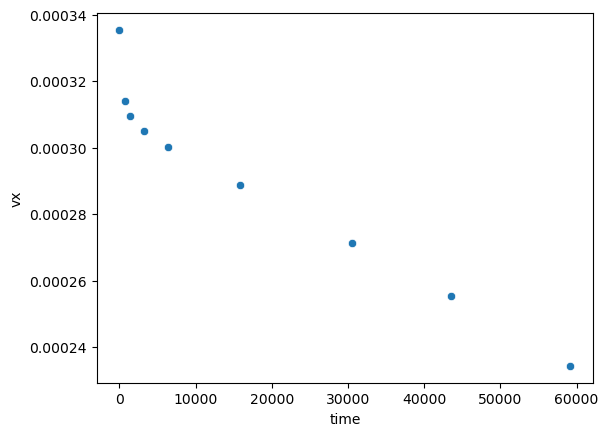

In [51]:
sns.scatterplot(data=df, x="time", y="vx")

KeyboardInterrupt: 

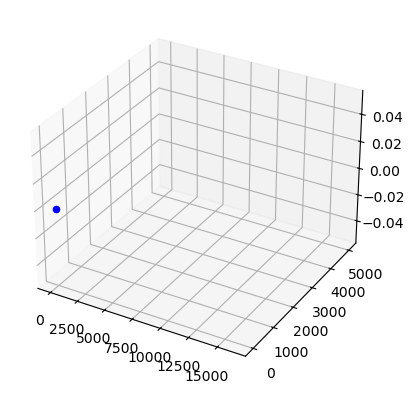

In [52]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d') 
ani = orb.plot_trajectory_3d(fig, ax, start_index=0, frames=200, interval=50)
HTML(ani.to_jshtml())


In [ ]:
(G * 1*u.Msun / c**2).to(u.Rsun)

<Quantity 2.12250257e-06 solRad>

In [ ]:
1*u.Rsun

<Quantity 1. solRad>

In [ ]:
Gweird = G.to(u.AU**(3) / (u.Msun*u.yr**2)) * (2*np.pi/1*u.yr)**2

In [ ]:
(Gweird * 1*u.Msun / c**2) * (2*np.pi/1*u.yr)**(-2)

<Quantity 4.39240044e-16 AU3 s2 / (m2 yr2)>